In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

repo_root = Path(r"C:\Users\Harsh\AeroSentinel")
ai_service_dir = repo_root / "ai-service"

if str(ai_service_dir) not in sys.path:
    sys.path.insert(0, str(ai_service_dir))

train_path = repo_root / "data" / "processed" / "train_dataset.parquet"
val_path = repo_root / "data" / "processed" / "val_dataset.parquet"

train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)

# Load forecast models artifact
model_path = ai_service_dir / "models" / "artifacts" / "forecast_regressors_v1.joblib"
forecast_artifact = joblib.load(model_path)

models = forecast_artifact["models"]
features = forecast_artifact["feature_cols"]
residuals = forecast_artifact.get("residuals", {})

print(f"Loaded validation set: {len(val_df):,} rows")
print(f"Features loaded: {len(features)}")
print(f"Available horizons: {[k for k in models.keys() if isinstance(k, int)]}")

c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded validation set: 10,528 rows
Features loaded: 36
Available horizons: [1, 3, 6]


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

metrics_records = []
current_pm25_col = "pm25_clean" if "pm25_clean" in val_df.columns else "pm25"

for h in [1, 3, 6]:
    target_col = f"target_pm25_t_plus_{h}"
    valid_mask = val_df[target_col].notna() & val_df[current_pm25_col].notna()
    subset = val_df[valid_mask]
    
    y_true = subset[target_col].values
    y_naive = subset[current_pm25_col].values
    
    # Model predictions
    regressor = models[h]
    X_val = subset[features].fillna(0.0)
    y_pred = regressor.predict(X_val)
    
    # Naive Persistence Baseline
    metrics_records.append({
        "Horizon": f"T+{h}h",
        "Model": "Naive Persistence",
        "MAE": round(float(mean_absolute_error(y_true, y_naive)), 2),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_naive))), 2),
        "R2": round(float(r2_score(y_true, y_naive)), 4)
    })
    
    # Random Forest Regressor
    metrics_records.append({
        "Horizon": f"T+{h}h",
        "Model": "Random Forest Regressor",
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 2),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
        "R2": round(float(r2_score(y_true, y_pred)), 4)
    })

metrics_df = pd.DataFrame(metrics_records)
metrics_df

,Horizon,Model,MAE,RMSE,R2
0,T+1h,Naive Persistence,0.89,5.35,0.8189
1,T+1h,Random Forest Regressor,1.66,6.71,0.7149
2,T+3h,Naive Persistence,2.76,10.42,0.2464
3,T+3h,Random Forest Regressor,2.84,8.19,0.5342
4,T+6h,Naive Persistence,3.97,12.40,-0.1538
5,T+6h,Random Forest Regressor,4.45,10.87,0.1120


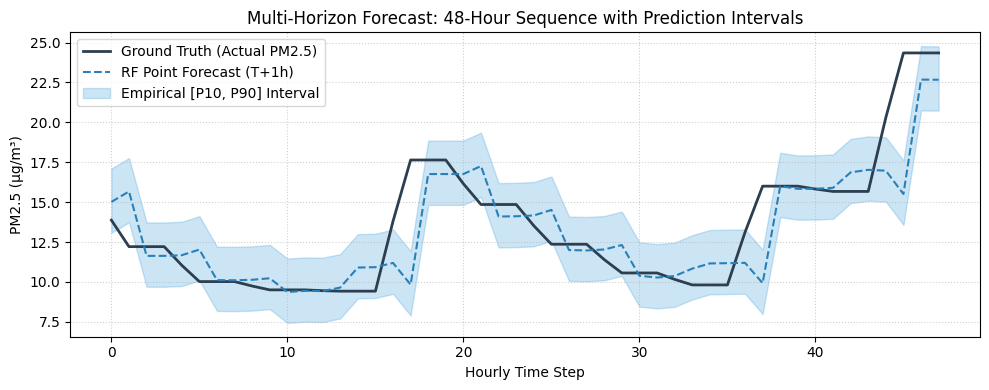

In [7]:
# Visualize a continuous 48-hour time series slice with P10-P90 prediction intervals
sample_slice = val_df.dropna(subset=["target_pm25_t_plus_1"]).iloc[100:148]
X_slice = sample_slice[features].fillna(0.0)

t1_model = models[1]
point_preds = t1_model.predict(X_slice)
p10_res = residuals.get(1, {}).get("p10", -1.93)
p90_res = residuals.get(1, {}).get("p90", 2.09)

lower_bound = np.maximum(0.0, point_preds + p10_res)
upper_bound = point_preds + p90_res
actuals = sample_slice["target_pm25_t_plus_1"].values

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(actuals, label="Ground Truth (Actual PM2.5)", color="#2c3e50", linewidth=2)
ax.plot(point_preds, label="RF Point Forecast (T+1h)", color="#2980b9", linestyle="--", linewidth=1.5)
ax.fill_between(range(len(point_preds)), lower_bound, upper_bound, color="#3498db", alpha=0.25, label="Empirical [P10, P90] Interval")

ax.set_title("Multi-Horizon Forecast: 48-Hour Sequence with Prediction Intervals")
ax.set_xlabel("Hourly Time Step")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()